In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39085,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44052,Total threads: 6
Dashboard: http://127.0.0.1:42625/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:35623,


In [4]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [5]:
from utils import *

In [6]:
data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

In [7]:
ISOBLJ = ISOBLJ_Struct(input_data,data=data)

In [8]:
# ISOBLJ.data
ISOBLJ.open_datasets(prefix=['vels'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
# ISOBLJ.data['dz8']['expt'].pop("c80m_Td2_vshift8_ryan_dz8")
# ISOBLJ.data['dz4']['expt'].pop("c80m_Td2_vshift16_ryan_dz4")
ISOBLJ.data['dz2']['expt'].pop("c80m_Td2_vshift48_visc_dz2")

{'exec': True,
 'dims': {'nx': np.float64(60.0),
  'ny': np.float64(160.0),
  'nz': np.float64(256.0),
  'dx': np.float64(60.0),
  'dy': np.float64(60.0),
  'dz': np.float64(2.0)},
 'timestep': array(4.),
 'data': <xarray.Dataset> Size: 5GB
 Dimensions:  (XC: 60, YC: 160, XG: 60, YG: 160, Z: 256, Zp1: 257, Zu: 256,
               Zl: 256, time: 171)
 Coordinates: (12/34)
   * XC       (XC) float32 240B 0.03 0.09 0.15 0.21 0.27 ... 3.39 3.45 3.51 3.57
   * YC       (YC) float32 640B 0.03 0.09 0.15 0.21 0.27 ... 9.39 9.45 9.51 9.57
   * XG       (XG) float32 240B 0.0 0.06 0.12 0.18 0.24 ... 3.36 3.42 3.48 3.54
   * YG       (YG) float32 640B 0.0 0.06 0.12 0.18 0.24 ... 9.36 9.42 9.48 9.54
   * Z        (Z) >f4 1kB -1.0 -3.0 -5.0 -7.0 ... -505.0 -507.0 -509.0 -511.0
   * Zp1      (Zp1) >f4 1kB 0.0 -2.0 -4.0 -6.0 ... -506.0 -508.0 -510.0 -512.0
     ...       ...
     dxF      (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
     rhoRef   (Z) >f4 1kB dask.array<chunksize=

In [10]:
Uvel = ISOBLJ.get_variable("UVEL")
Vvel = ISOBLJ.get_variable("VVEL")
Wvel = ISOBLJ.get_variable("WVEL")

In [11]:
def find_coord(var,coord):
    for vcoord in var[0].coords:
        if coord in vcoord:
            return vcoord

In [12]:
# dx = var[0][find_coord(var,"dx")][0,0].values

In [13]:
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from plot_utils import *
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [14]:
var_units=r"U [$m/s$]"

In [15]:
# real_hfac = Uvel.UVEL_c0m_Td2_s089p_dz8.hFacW_c0m_Td2_s089p_dz8
# print(real_hfac.shape)
# print(hfacc.shape)

In [16]:
from plot_utils import *

## Plot different channel depths

In [17]:
# np.sort(Uvel.data_vars)
import re

def tryint(s):
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """ Turn a string into a list of string and number chunks.
        "z23a" -> ["z", 23, "a"]
    """
    return [ tryint(c) for c in re.split('([0-9]+)', s) ]

def sort_nicely(l):
    """ Sort the given list in the way that humans expect.
    """
    l.sort(key=alphanum_key)

var_names = list(Uvel.data_vars)
sort_nicely(var_names)

In [41]:
from matplotlib.transforms import Bbox

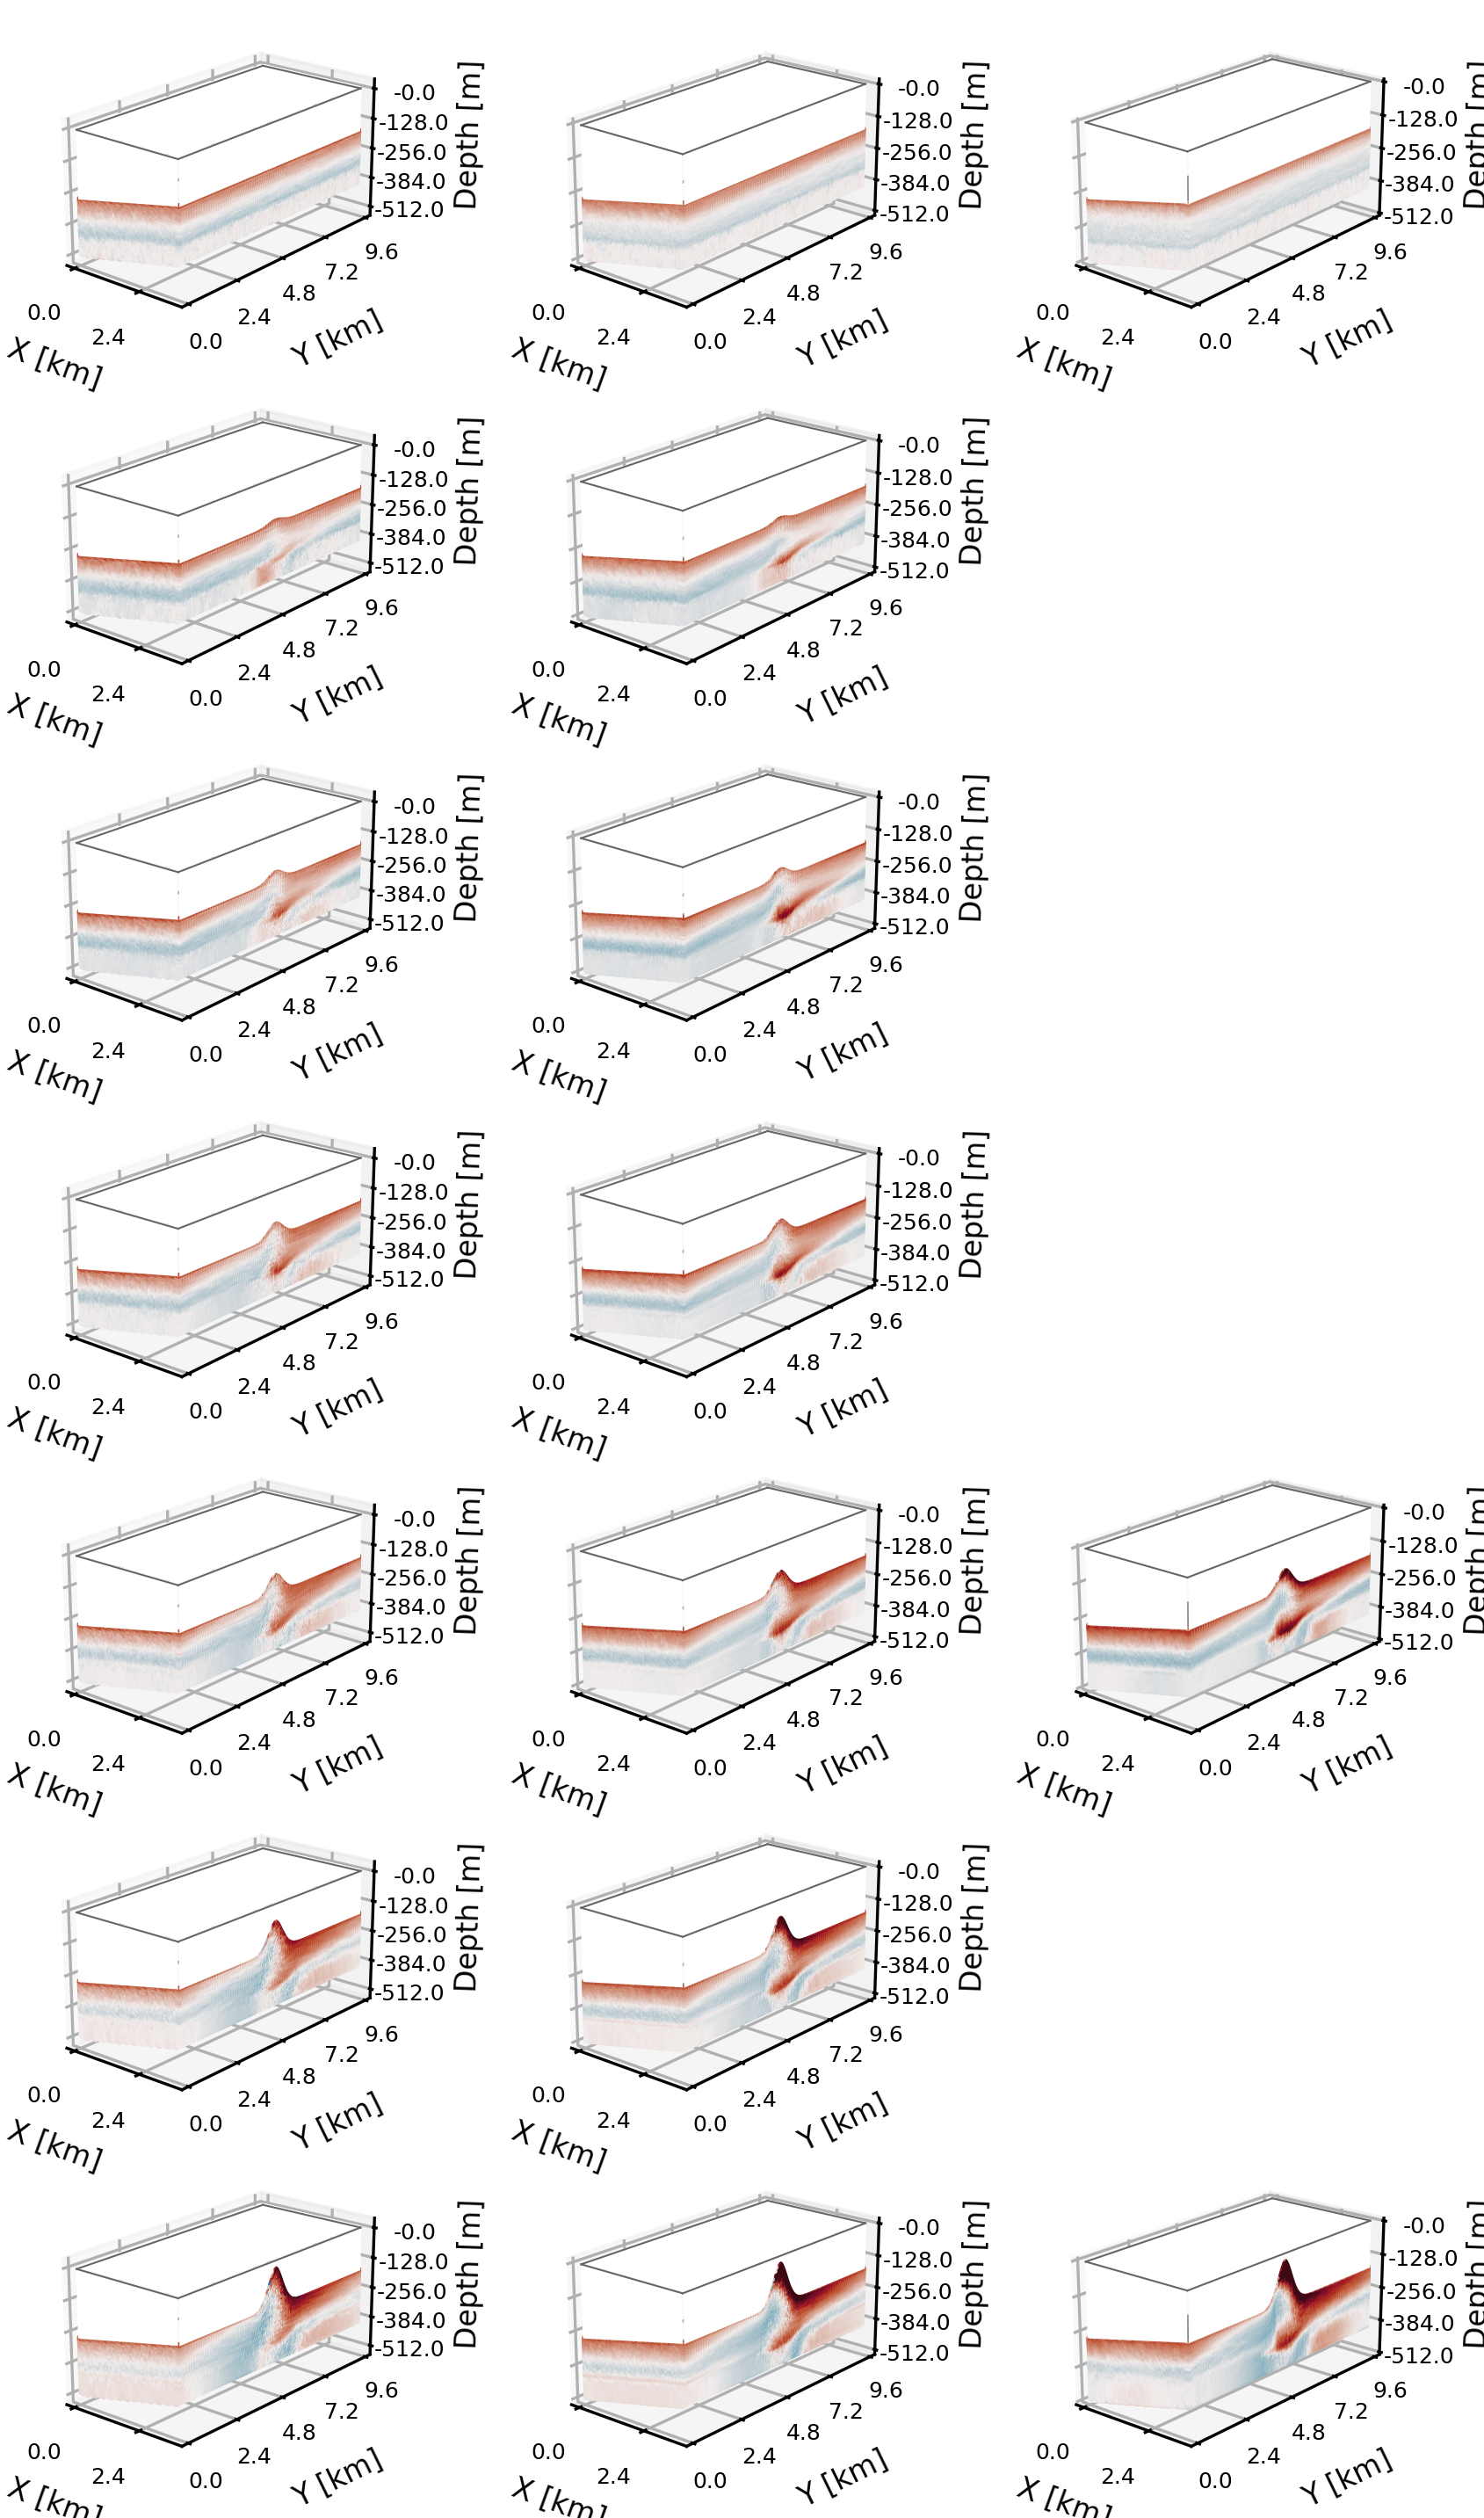

In [56]:
fig = plt.figure(figsize=(7, 12),dpi=300)

time=-1

gs = GridSpec(7, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax2 = fig.add_subplot(gs[1, 0], projection='3d')
ax3 = fig.add_subplot(gs[2, 0], projection='3d')
ax4 = fig.add_subplot(gs[3, 0], projection='3d')
ax5 = fig.add_subplot(gs[4, 0], projection='3d')
ax6 = fig.add_subplot(gs[5, 0], projection='3d')
ax7 = fig.add_subplot(gs[6, 0], projection='3d')

ax = [ax1,ax2,ax3,ax4,ax5,ax6,ax7]

counter =0
for var in var_names:
    if "Td2" in var and "vshift12" in var and "dz8" in var:
        coor = [ coor for coor in  Uvel[var].coords if "Z" in coor]
        variable = Uvel[var].transpose(...,coor[0])
        # variable.isel(time=-1).mean("XG").plot(x="YC",ax=axs[counter],cmap=cm.cm.delta)
        
        dx = variable[find_coord(variable,"dx")][0,0].values/1000
        dy = variable[find_coord(variable,"dy")][0,0].values/1000
        dz = -variable[find_coord(variable,"dr")][0].values
        # dz = abs(sim[find_coord(sim,"Z")].diff('Z')[0].values)
    
        kw = {
            'vmin': -0.2,
            'vmax': 0.2,
            # 'vmax': vmax,
            # 'levels': np.linspace(vmin, vmax, 20),
            'cmap': cm.cm.balance,
        }
        hfacc_var = [coord for coord in Uvel[var].coords if "hFac" in coord]
        hfacc = variable[var.replace(var.split("_")[0],hfacc_var[0].split("_")[0])]
        
        var2plot = (variable.isel(time=time))
        var2plot = var2plot.where(var2plot!=0).values
        
        cbar = plot_imshow3D(ax[counter],var2plot,dgrid=(dx,dy,dz),kw=kw)
        
        hfacc_shape = hfacc.shape[-1]
        hfacc_surf, hfacc_depth = construct_hfacc_surfaces(hfacc.values,abs(dz))
        # Divide by dz to match the number of pixels of imshow.
        vert_top = get_faces(hfacc_surf/abs(dz) + 0.5 ,z_shift=-1,delta_expand=0.5)  # Add half of a pixel
        vert_bottom = get_faces(hfacc_depth/abs(dz),z_shift=41,flip=True)#get_faces(hfacc_surf/abs(dz),z_shift=3)
        plot_hfacc_surf_3D(vert_top,vert_bottom,ax=ax[counter])
        
        ax[counter].set_title(var)
        counter+=1
        
[ a.invert_zaxis() for a in ax]
[ a.set_title("") for a in ax]

[a.set_box_aspect((1,2,1),zoom=1.2) for a in ax] 

[a.set_xlabel("X [km]", fontsize=8, labelpad=-8) for a in ax] 
[a.set_ylabel("Y [km] \n \n \n", fontsize=8, labelpad=-8) for a in ax] 

[a.set_zlabel("Depth [m]", fontsize=8, labelpad=-6) for a in ax] 
[a.tick_params(axis="x", pad=-2) for a in ax] 
[a.tick_params(axis="y", pad=-2) for a in ax] 
[a.tick_params(axis="z", pad=-2) for a in ax] 

[a.xaxis.set_major_locator(plt.MaxNLocator(2))  for a in ax]


for a in ax:
    a.yaxis.labelpad=8
    a.yaxis.set_tick_params(labelsize=6)
    a.xaxis.set_tick_params(labelsize=6)
    a.zaxis.set_tick_params(labelsize=6)
    
# cbar_ax = fig.add_axes([0.1, 0.3, 0.01, 0.4])
# fig.colorbar(cbar, cax =cbar_ax)
# cbar_ax.set_title(var_units,fontsize=8)
# cbar_ax.yaxis.set_tick_params(labelsize=6)

########################################################
########################################################
########################################################

ax1 = fig.add_subplot(gs[0, 1], projection='3d')
ax2 = fig.add_subplot(gs[1, 1], projection='3d')
ax3 = fig.add_subplot(gs[2, 1], projection='3d')
ax4 = fig.add_subplot(gs[3, 1], projection='3d')
ax5 = fig.add_subplot(gs[4, 1], projection='3d')
ax6 = fig.add_subplot(gs[5, 1], projection='3d')
ax7 = fig.add_subplot(gs[6, 1], projection='3d')

ax = [ax1,ax2,ax3,ax4,ax5,ax6,ax7]

counter =0
for var in var_names:
    if "Td2" in var and "vshift24" in var and "dz4" in var:
        coor = [ coor for coor in  Uvel[var].coords if "Z" in coor]
        variable = Uvel[var].transpose(...,coor[0])
        # variable.isel(time=-1).mean("XG").plot(x="YC",ax=axs[counter],cmap=cm.cm.delta)
        
        dx = variable[find_coord(variable,"dx")][0,0].values/1000
        dy = variable[find_coord(variable,"dy")][0,0].values/1000
        dz = -variable[find_coord(variable,"dr")][0].values
        # dz = abs(sim[find_coord(sim,"Z")].diff('Z')[0].values)
    
        kw = {
            'vmin': -0.2,
            'vmax': 0.2,
            # 'vmax': vmax,
            # 'levels': np.linspace(vmin, vmax, 20),
            'cmap': cm.cm.balance,
        }
        hfacc_var = [coord for coord in Uvel[var].coords if "hFac" in coord]
        hfacc = variable[var.replace(var.split("_")[0],hfacc_var[0].split("_")[0])]
        
        var2plot = (variable.isel(time=time))
        var2plot = var2plot.where(var2plot!=0).values
        
        cbar = plot_imshow3D(ax[counter],var2plot,dgrid=(dx,dy,dz),kw=kw)
        
        hfacc_shape = hfacc.shape[-1]
        hfacc_surf, hfacc_depth = construct_hfacc_surfaces(hfacc.values,abs(dz))
        # Divide by dz to match the number of pixels of imshow.
        vert_top = get_faces(hfacc_surf/abs(dz) + 0.5 ,z_shift=-1,delta_expand=0.5)  # Add half of a pixel
        vert_bottom = get_faces(hfacc_depth/abs(dz),z_shift=41,flip=True)#get_faces(hfacc_surf/abs(dz),z_shift=3)
        plot_hfacc_surf_3D(vert_top,vert_bottom,ax=ax[counter])
        
        ax[counter].set_title(var)
        counter+=1
        
[ a.invert_zaxis() for a in ax]

[a.set_box_aspect((1,2,1),zoom=1.2) for a in ax] 

[a.set_xlabel("X [km]", fontsize=8, labelpad=-8) for a in ax] 
[a.set_ylabel("Y [km] \n \n \n", fontsize=8, labelpad=-8) for a in ax] 
[a.set_title("") for a in ax]

[a.set_zlabel("Depth [m]", fontsize=8, labelpad=-6) for a in ax] 
[a.tick_params(axis="x", pad=-2) for a in ax] 
[a.tick_params(axis="y", pad=-2) for a in ax] 
[a.tick_params(axis="z", pad=-2) for a in ax] 

[a.xaxis.set_major_locator(plt.MaxNLocator(2))  for a in ax]


for a in ax:
    a.yaxis.labelpad=8
    a.yaxis.set_tick_params(labelsize=6)
    a.xaxis.set_tick_params(labelsize=6)
    a.zaxis.set_tick_params(labelsize=6)

########################################################
########################################################
########################################################


ax1 = fig.add_subplot(gs[0, 2], projection='3d')
# ax2 = fig.add_subplot(gs[1, 2], projection='3d')
# ax3 = fig.add_subplot(gs[2, 2], projection='3d')
# ax4 = fig.add_subplot(gs[3, 2], projection='3d')
ax5 = fig.add_subplot(gs[4, 2], projection='3d')
# ax6 = fig.add_subplot(gs[5, 2], projection='3d')
ax7 = fig.add_subplot(gs[6, 2], projection='3d')

ax = [ax1,ax5,ax7]

counter =0
for var in var_names:
    if "Td2" in var and "vshift48" in var and "dz2" in var:
        coor = [ coor for coor in  Uvel[var].coords if "Z" in coor]
        variable = Uvel[var].transpose(...,coor[0])
        # variable.isel(time=-1).mean("XG").plot(x="YC",ax=axs[counter],cmap=cm.cm.delta)
        
        dx = variable[find_coord(variable,"dx")][0,0].values/1000
        dy = variable[find_coord(variable,"dy")][0,0].values/1000
        dz = -variable[find_coord(variable,"dr")][0].values
        # dz = abs(sim[find_coord(sim,"Z")].diff('Z')[0].values)
    
        kw = {
            'vmin': -0.2,
            'vmax': 0.2,
            # 'vmax': vmax,
            # 'levels': np.linspace(vmin, vmax, 20),
            'cmap': cm.cm.balance,
        }
        hfacc_var = [coord for coord in Uvel[var].coords if "hFac" in coord]
        hfacc = variable[var.replace(var.split("_")[0],hfacc_var[0].split("_")[0])]
        
        var2plot = (variable.isel(time=time))
        var2plot = var2plot.where(var2plot!=0).values
        
        cbar = plot_imshow3D(ax[counter],var2plot,dgrid=(dx,dy,dz),kw=kw)
        
        hfacc_shape = hfacc.shape[-1]
        hfacc_surf, hfacc_depth = construct_hfacc_surfaces(hfacc.values,abs(dz))
        # Divide by dz to match the number of pixels of imshow.
        vert_top = get_faces(hfacc_surf/abs(dz) + 0.5 ,z_shift=-1,delta_expand=0.5)  # Add half of a pixel
        vert_bottom = get_faces(hfacc_depth/abs(dz),z_shift=41,flip=True)#get_faces(hfacc_surf/abs(dz),z_shift=3)
        plot_hfacc_surf_3D(vert_top,vert_bottom,ax=ax[counter])
        
        ax[counter].set_title(var)
        counter+=1
        
[ a.invert_zaxis() for a in ax]

[a.set_box_aspect((1,2,1),zoom=1.2) for a in ax] 

[a.set_xlabel("X [km]", fontsize=8, labelpad=-8) for a in ax] 
[a.set_ylabel("Y [km] \n \n \n", fontsize=8, labelpad=-8) for a in ax] 
[a.set_title("") for a in ax]

[a.set_zlabel("Depth [m]", fontsize=8, labelpad=-6) for a in ax] 
[a.tick_params(axis="x", pad=-2) for a in ax] 
[a.tick_params(axis="y", pad=-2) for a in ax] 
[a.tick_params(axis="z", pad=-2) for a in ax] 

[a.xaxis.set_major_locator(plt.MaxNLocator(2))  for a in ax]


for a in ax:
    a.yaxis.labelpad=8
    a.yaxis.set_tick_params(labelsize=6)
    a.xaxis.set_tick_params(labelsize=6)
    a.zaxis.set_tick_params(labelsize=6)

# plt.tight_layout()

# plt.savefig("./figures/Fig_2_velocities.png", dpi=300, bbox_inches='tight')

plt.subplots_adjust(wspace=0.05)

plt.savefig("./figures/Fig_2_velocities.png", dpi=300, bbox_inches=Bbox([[0,0],fig.get_size_inches()]))


In [43]:
fig.get_size_inches()

array([ 7., 12.])